# Figure 2: finite-strain Poisson ratio
All quantities are dimensionless; $V_0=1$ and $\kappa=0.1$. Run all cells in order.

In [1]:
# Locate the bundled simulator without requiring an editable installation.
from pathlib import Path
import sys
import tomllib

package_root = None
cwd = Path.cwd().resolve()
for candidate in (cwd, *cwd.parents):
    project_file = candidate / "pyproject.toml"
    if project_file.is_file() and (candidate / "cvm3d" / "__init__.py").is_file():
        project = tomllib.loads(project_file.read_text(encoding="utf-8"))
        if project.get("project", {}).get("name") == "epithelial-cvm3d":
            package_root = candidate
            break

if package_root is not None:
    loaded = sys.modules.get("cvm3d")
    if (
        loaded is not None
        and Path(loaded.__file__).resolve().parent != package_root / "cvm3d"
    ):
        raise RuntimeError(
            "Another cvm3d package is loaded. Restart the kernel and run all cells."
        )
    sys.path.insert(0, str(package_root))

import jax

jax.config.update("jax_enable_x64", True)
import cvm3d


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize_scalar

SQRT3 = np.sqrt(3.0)
KAPPA = 0.1
V0 = 1.0

plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "font.size": 7,
        "axes.labelsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "lines.linewidth": 0.75,
        "axes.linewidth": 0.5,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.major.size": 2,
        "ytick.major.size": 2,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

MM_TO_INCH = 1.0 / 25.4


## Affine energy and elastic moduli
$K=E_{\epsilon\epsilon}/(4A_{b0})$ for isotropic axial strain; $G=E_{\epsilon\epsilon}/(4A_{b0})$ for area-preserving pure shear. $\nu=(K-G)/(K+G)$.

In [3]:
def energy_isotropic(l, param, *, kappa=KAPPA, V0=V0):
    gamma_b, gamma_c, sigma = param
    if np.any(np.asarray(l) <= 0):
        return np.inf
    return (
        1.5 * SQRT3 * gamma_b * l**2
        + (2.0 * SQRT3 / 3.0) * gamma_c * V0 / l
        + 6.0 * sigma * l
        + kappa * (32.0 / (3.0 * l**2) + 27.0 * l**4 / V0**2)
    )


def _positive_global_minimum(fun, bounds=(1e-4, 1e2), samples=500):
    """Log-grid bracket followed by bounded minimization."""
    lo, hi = bounds
    if not (0 < lo < hi):
        raise ValueError("bounds must satisfy 0 < lower < upper")

    log_grid = np.linspace(np.log(lo), np.log(hi), samples)
    values = np.array([fun(np.exp(x)) for x in log_grid])
    i = int(np.nanargmin(values))
    if i in (0, samples - 1):
        raise RuntimeError("minimum reached a search bound; enlarge bounds")

    result = minimize_scalar(
        lambda x: fun(np.exp(x)),
        bounds=(log_grid[i - 1], log_grid[i + 1]),
        method="bounded",
        options={"xatol": 1e-11},
    )
    if not result.success:
        raise RuntimeError(f"minimization failed: {result.message}")
    return float(np.exp(result.x))


def find_ground_state_l(param, bounds=(1e-4, 1e2)):
    return _positive_global_minimum(lambda l: energy_isotropic(l, param), bounds=bounds)


def bulk_modulus(l, param, *, kappa=KAPPA, V0=V0):
    gamma_b, gamma_c, sigma = param
    return (
        gamma_b / 2.0
        + 2.0 * V0 * gamma_c / (9.0 * l**3)
        + 32.0 * SQRT3 * kappa / (9.0 * l**4)
        + 18.0 * SQRT3 * kappa * l**2 / V0**2
    )


def shear_modulus(l, param, *, kappa=KAPPA, V0=V0):
    gamma_b, gamma_c, sigma = param
    return (
        V0 * gamma_c / (6.0 * l**3)
        + SQRT3 * sigma / (2.0 * l)
        + 64.0 * SQRT3 * kappa / (27.0 * l**4)
    )


def poisson_ratio_theory(l, param):
    K = bulk_modulus(l, param)
    G = shear_modulus(l, param)
    return (K - G) / (K + G)


## Finite uniaxial deformation
$F=\mathrm{diag}(\alpha,\beta,(\alpha\beta)^{-1})$. Two hexagon edges are parallel to $y$.
$P=2l\beta+2l\sqrt{3\alpha^2+\beta^2}$ and
$E_\star=16\kappa(\alpha^{-2}+\beta^{-2})/(3l^2)+4\kappa(\alpha\beta)^2/h_0^2$.
Minimize over $\beta>0$; $\nu_{\rm num}=-(\beta-1)/\epsilon$ for $\alpha=1+\epsilon$.

In [4]:
def energy_deformed(beta, param, alpha, l0, *, kappa=KAPPA, V0=V0):
    gamma_b, gamma_c, sigma = param
    if alpha <= 0 or beta <= 0 or l0 <= 0:
        return np.inf

    Ab0 = 1.5 * SQRT3 * l0**2
    h0 = V0 / Ab0
    perimeter = 2.0 * l0 * beta + 2.0 * l0 * np.sqrt(3.0 * alpha**2 + beta**2)
    basal_area = Ab0 * alpha * beta
    height = h0 / (alpha * beta)
    lateral_area = height * perimeter
    edge_star = (
        16.0 * kappa / (3.0 * l0**2) * (alpha**-2 + beta**-2)
        + 4.0 * kappa * (alpha * beta) ** 2 / h0**2
    )
    return (
        gamma_b * basal_area
        + 0.5 * gamma_c * lateral_area
        + sigma * perimeter
        + edge_star
    )


def relaxed_beta(param, alpha, l0, bounds=(2e-2, 20.0)):
    return _positive_global_minimum(
        lambda beta: energy_deformed(beta, param, alpha, l0),
        bounds=bounds,
        samples=300,
    )


def poisson_ratio_numerical(param, strain=0.05):
    if strain == 0 or strain <= -1:
        raise ValueError("strain must be nonzero and greater than -1")
    l0 = find_ground_state_l(param)
    beta = relaxed_beta(param, 1.0 + strain, l0)
    return -(beta - 1.0) / strain


# Consistency checks at a representative point.
_test_param = (-1.0, -1.0, 1.0)
_test_l = find_ground_state_l(_test_param)
assert np.isclose(
    energy_deformed(1.0, _test_param, 1.0, _test_l),
    energy_isotropic(_test_l, _test_param),
    rtol=1e-12,
    atol=1e-12,
)
assert np.isclose(relaxed_beta(_test_param, 1.0, _test_l), 1.0, atol=2e-6)


In [5]:
def phase_diagram(gamma_b, gamma_c_values, sigma_values, *, strain=None):
    result = np.full((len(sigma_values), len(gamma_c_values)), np.nan)
    for i, sigma in enumerate(sigma_values):
        for j, gamma_c in enumerate(gamma_c_values):
            param = (gamma_b, gamma_c, sigma)
            try:
                if strain is None:
                    l0 = find_ground_state_l(param)
                    result[i, j] = poisson_ratio_theory(l0, param)
                else:
                    result[i, j] = poisson_ratio_numerical(param, strain=strain)
            except (RuntimeError, ValueError, FloatingPointError):
                pass
    return result


def line_scan(values, make_param, strains=(0.01, 0.05, 0.10, 0.30)):
    theory = np.full(len(values), np.nan)
    numerical = {eps: np.full(len(values), np.nan) for eps in strains}
    for i, value in enumerate(values):
        param = make_param(value)
        try:
            l0 = find_ground_state_l(param)
            theory[i] = poisson_ratio_theory(l0, param)
            for eps in strains:
                numerical[eps][i] = poisson_ratio_numerical(param, strain=eps)
        except (RuntimeError, ValueError, FloatingPointError):
            pass
    return theory, numerical


def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


## Panels a and b: linear prediction and 5% strain

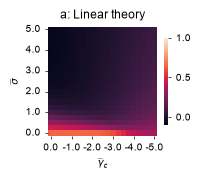

In [6]:
width_mm, height_mm = 48.0, 48.0
mm_to_inch = 1.0 / 25.4
figsize_inch = (width_mm * mm_to_inch, height_mm * mm_to_inch)

fig, ax = plt.subplots(1, 1, figsize=figsize_inch)
fig.subplots_adjust(left=0.18)

gamma_b = -1.0
gamma_c_grid = np.linspace(0.0, -5.0, 21)
sigma_grid = np.linspace(0.0, 5.0, 21)

nu_theory = phase_diagram(gamma_b, gamma_c_grid, sigma_grid)

sns.heatmap(
    nu_theory, ax=ax, vmin=-0.1, vmax=1.0, square=True, cbar_kws={"shrink": 0.6}
)
ax.invert_yaxis()
n_sigma = len(sigma_grid)
n_gamma = len(gamma_c_grid)

ticks_pos_y = [int(round(i * (n_sigma - 1) / 5)) for i in range(6)]
ticks_lbl_y = [f"{v:.1f}" for v in np.round(sigma_grid[ticks_pos_y], 1)]
ax.set_yticks(np.asarray(ticks_pos_y) + 0.5)
ax.set_yticklabels(ticks_lbl_y)


ticks_pos_x = [int(round(i * (n_gamma - 1) / 5)) for i in range(6)]
ticks_lbl_x = [f"{v:.1f}" for v in np.round(gamma_c_grid[ticks_pos_x], 1)]
ax.set_xticks(np.asarray(ticks_pos_x) + 0.5)
ax.set_xticklabels(ticks_lbl_x, rotation=0)
ax.set_xlabel(r"$\widetilde\gamma_c$")
ax.set_ylabel(r"$\widetilde\sigma$")
ax.set_title("a: Linear theory")
plt.show()


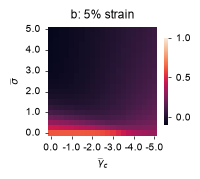

In [7]:
width_mm, height_mm = 48.0, 48.0
mm_to_inch = 1.0 / 25.4
figsize_inch = (width_mm * mm_to_inch, height_mm * mm_to_inch)

fig, ax = plt.subplots(1, 1, figsize=figsize_inch)
fig.subplots_adjust(left=0.18)

nu_numerical = phase_diagram(gamma_b, gamma_c_grid, sigma_grid, strain=0.05)

sns.heatmap(
    nu_numerical, ax=ax, vmin=-0.1, vmax=1.0, square=True, cbar_kws={"shrink": 0.6}
)
ax.invert_yaxis()
n_sigma = len(sigma_grid)
n_gamma = len(gamma_c_grid)

ticks_pos_y = [int(round(i * (n_sigma - 1) / 5)) for i in range(6)]
ticks_lbl_y = [f"{v:.1f}" for v in np.round(sigma_grid[ticks_pos_y], 1)]
ax.set_yticks(np.asarray(ticks_pos_y) + 0.5)
ax.set_yticklabels(ticks_lbl_y)


ticks_pos_x = [int(round(i * (n_gamma - 1) / 5)) for i in range(6)]
ticks_lbl_x = [f"{v:.1f}" for v in np.round(gamma_c_grid[ticks_pos_x], 1)]
ax.set_xticks(np.asarray(ticks_pos_x) + 0.5)
ax.set_xticklabels(ticks_lbl_x, rotation=0)
ax.set_xlabel(r"$\widetilde\gamma_c$")
ax.set_ylabel(r"$\widetilde\sigma$")
ax.set_title("b: 5% strain")
plt.show()


## Theory versus finite strain along two parameter lines

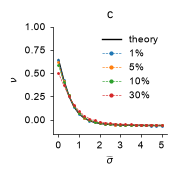

In [8]:
strains = (0.01, 0.05, 0.10, 0.30)
theory_sigma, numerical_sigma = line_scan(
    sigma_grid,
    lambda sigma: (gamma_b, -1.0, sigma),
    strains=strains,
)

fig, ax = plt.subplots(figsize=(40 * MM_TO_INCH, 40 * MM_TO_INCH))
ax.plot(sigma_grid, theory_sigma, color="black", linewidth=1.0, label="theory")
for eps, values in numerical_sigma.items():
    ax.plot(
        sigma_grid,
        values,
        "--o",
        markersize=1.0,
        linewidth=0.45,
        label=f"{eps:.0%}",
    )
ax.set_ylim(-0.15, 1.0)
ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.legend(frameon=False, markerscale=2, handlelength=2)
style_axis(ax)
fig.subplots_adjust(left=0.18, bottom=0.20)
ax.set_xlabel(r"$\widetilde\sigma$")
ax.set_ylabel(r"$\nu$")
ax.set_title("c")
plt.show()


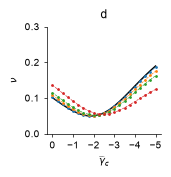

In [9]:
strains = (0.01, 0.05, 0.10, 0.30)
theory_gc, numerical_gc = line_scan(
    gamma_c_grid,
    lambda gamma_c: (gamma_b, gamma_c, 1.0),
    strains=strains,
)

fig, ax = plt.subplots(figsize=(40 * MM_TO_INCH, 40 * MM_TO_INCH))
ax.plot(gamma_c_grid, theory_gc, color="black", linewidth=1.0, label="theory")
for eps, values in numerical_gc.items():
    ax.plot(
        gamma_c_grid,
        values,
        "--o",
        markersize=1.0,
        linewidth=0.45,
        label=f"{eps:.0%}",
    )
ax.set_ylim(0.0, 0.30)
ax.set_xticks([0, -1, -2, -3, -4, -5])
style_axis(ax)
ax.invert_xaxis()
fig.subplots_adjust(left=0.18, bottom=0.20)
ax.set_xlabel(r"$\widetilde\gamma_c$")
ax.set_ylabel(r"$\nu$")
ax.set_title("d")
plt.show()
